### Analyzing a day of peak bloom to see if have same sinking dynamics



In [1]:
### combine and filter dataframes


from pathlib import Path
import pandas as pd

def combine_csvs_with_filename(directory):
    """
    Combine all CSV files in a directory into one DataFrame.
    Adds a 'FileName' column containing the source filename.
    """
    dfs = []

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)
        df["FileName"] = file.name
        dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [15]:
master_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/nauset/20240429/nauset/merged")

In [16]:
def filter_alexandrium(master_df, alpha):
    """
    Return rows where any column beginning with 'Alexandrium'
    has a value greater than alpha.
    """
    alexandrium_cols = [
        col for col in master_df.columns
        if str(col).startswith("Alexandrium")
    ]

    if not alexandrium_cols:
        raise ValueError("No Alexandrium columns found in master_df.")

    mask = (
        master_df[alexandrium_cols]
        .apply(lambda col: col > alpha)
        .any(axis=1)
    )

    return master_df.loc[mask].copy()

In [17]:
alexfilt_df = filter_alexandrium(master_df, alpha=0.9)

print(f"Filtered DataFrame shape: {alexfilt_df.shape}")
print(f"Master dataframe shape: {master_df.shape}")

Filtered DataFrame shape: (105694, 151)
Master dataframe shape: (491955, 151)


Text(0.5, 1.0, 'Nauset 2024-04-29 to 2024-04-30 RunTime Distribution for Alexandrium > 0.9')

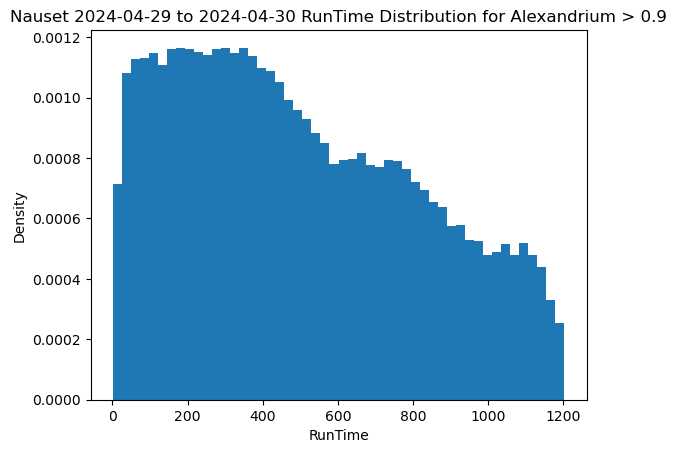

In [18]:
import matplotlib.pyplot as plt
plt.hist(alexfilt_df['RunTime'], bins=50, density=True)
plt.xlabel('RunTime')
plt.ylabel('Density')
plt.title('Nauset 2024-04-29 to 2024-04-30 RunTime Distribution for Alexandrium > 0.9')

KS statistic: 0.13678943294454987
p-value: 0.0


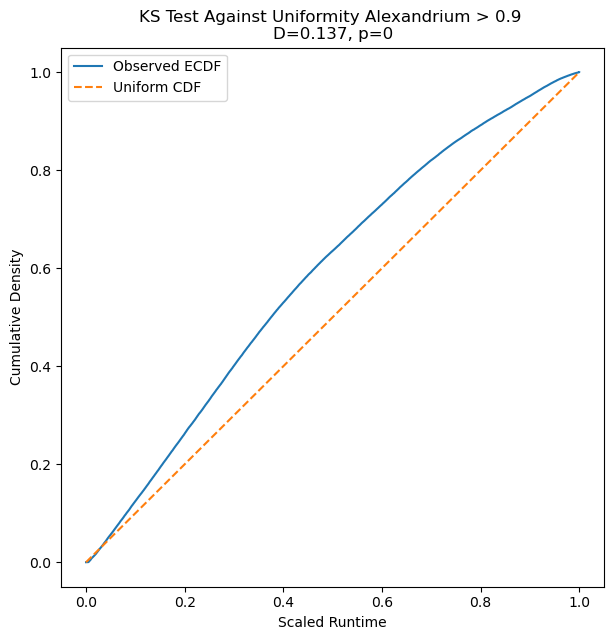

In [19]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(alexfilt_df["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Alexandrium > 0.9 \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chukchi/KS_test_Bivalves.png", dpi=300)

plt.show()

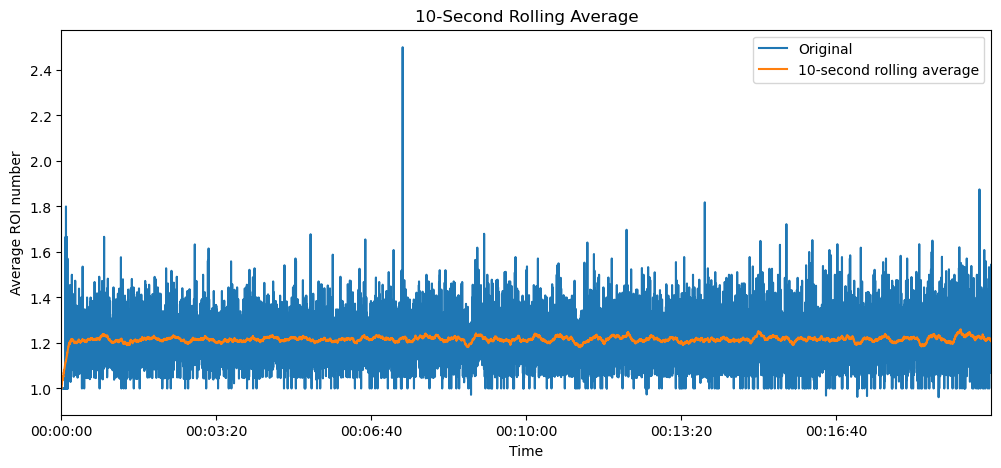

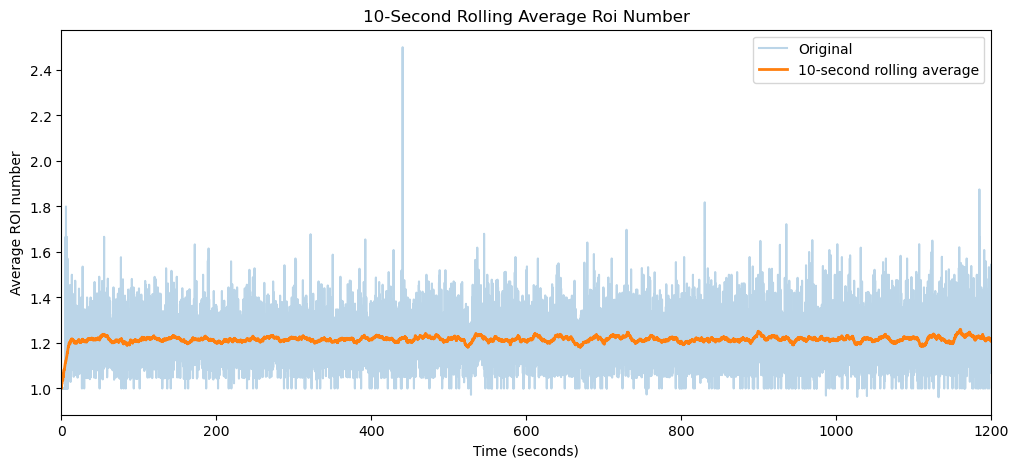

In [22]:
### Looking at ROI numbner over time 
import numpy as np
time_grid = np.linspace(0, 1200, 12001)  # 1200 time points from 0 to 1200 seconds
average_roi_number = []
for i in range(12000):
    start_time = time_grid[i]
    end_time = time_grid[i+1]
    time_df = master_df[(master_df["RunTime"] >= start_time) & (master_df["RunTime"] < end_time)]
    average_roi_number.append(time_df["RoiType"].mean())

roi_df = pd.DataFrame({
    "time": time_grid[:-1],
    "average_roi_number": average_roi_number
})

import pandas as pd
import matplotlib.pyplot as plt

plot_df = roi_df.copy()

plot_df["time"] = pd.to_timedelta(plot_df["time"], unit="s")
plot_df = plot_df.sort_values("time").set_index("time")

plot_df["rolling_avg"] = (
    plot_df["average_roi_number"]
    .rolling("10s", center=True, min_periods=1)
    .mean()
)

plot_df[["average_roi_number", "rolling_avg"]].plot(figsize=(12, 5))

plt.xlabel("Time")
plt.ylabel("Average ROI number")
plt.title("10-Second Rolling Average")
plt.legend(["Original", "10-second rolling average"])
plt.show()

x_seconds = plot_df.index.total_seconds()

plt.figure(figsize=(12, 5))
plt.plot(x_seconds, plot_df["average_roi_number"], alpha=0.3, label="Original")
plt.plot(x_seconds, plot_df["rolling_avg"], linewidth=2, label="10-second rolling average")

plt.xlim(0, 1200)
plt.xlabel("Time (seconds)")
plt.ylabel("Average ROI number")
plt.title("10-Second Rolling Average Roi Number")
plt.legend()
plt.show()